### CV Evaluator

In [31]:
import openai
# Core
import os
import re
import io
import logging
import pathlib
import sqlite3
from typing import TypedDict, List

# I/O and environment
from dotenv import load_dotenv, find_dotenv
from PyPDF2 import PdfReader
from IPython.display import display, Markdown, Image

# LangChain
from langchain_classic.chains import RetrievalQA, LLMChain, StuffDocumentsChain
from langchain_core.prompts import PromptTemplate
from langchain_community.document_loaders import TextLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Pinecone
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore

# LangGraph
from langgraph.graph import START, StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
#from langgraph.checkpoints.sqlite import SqliteSaver

# memory = SqliteSaver.from_conn_string(":memory:")

In [32]:
# Load enviroment
load_dotenv(find_dotenv())
memory = InMemorySaver()
openai_api_key = os.getenv("OPENAI_API_KEY")
pinecone_api_key = os.getenv('PINECONE')

# Set the api keys
openai.api_key =openai_api_key
client = openai.OpenAI()

MODEL_NAME = "gpt-4o-mini"

In [33]:
# Initialize OpenAIEmbedding from Langchain
embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)

pc = Pinecone(api_key=pinecone_api_key)

index = pc.Index("quickstart")

# Initialize Pinecone using Langchaing and sending the embedding
pinecone_vectorstore = PineconeVectorStore(index=index, embedding=embeddings)

In [34]:
## Load the files
def load_pdf_texts_from_folder(folder_path: str):
    all_docs = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".pdf"):
            pdf_path = os.path.join(folder_path, filename)
            loader = PyPDFLoader(pdf_path)
            pages = loader.load()
            all_docs.extend(pages)
            
    return all_docs


folder_path = pathlib.Path().resolve()
docs_in_folder = load_pdf_texts_from_folder(folder_path)
print(docs_in_folder)
texts = [doc.page_content for doc in docs_in_folder]
print(texts)

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2025-12-07T20:50:42+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2025-12-07T20:50:42+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'F:\\IA\\NLPII\\Ejercicios\\tp3\\ai_engineer_bigtech_cv.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Emily R. Stanton\nPrincipal AI Engineer & LLM Systems Architect\nContact Information\nEmail: emily.stanton.ai@example.com\nPhone: +1 (415) 555-9023\nLocation: Seattle, WA, USA\nLinkedIn: linkedin.com/in/emilystanton-LLM\nGitHub: github.com/emily-ml\nProfessional Summary\nPrincipal AI Engineer with 10+ years of experience designing large-scale AI and RAG systems at major\ntechnology companies including Google, Meta, and Microsoft. Expert in LLM architecture, retrieval\nsystems, distributed training pipelines, and high-performance inference. Proven success 

In [35]:

doc_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100, separators=["\n\n", "\n", ".", " "])
documents_for_evaluation = doc_splitter.split_documents(docs_in_folder)

In [36]:
# Index document definition
def index_documents():
    ids = [f"cv_{i+1}" for i in range(len(documents_for_evaluation))]
    pinecone_vectorstore.add_documents(
        documents=documents_for_evaluation,
        ids=ids
    )

In [37]:
# Instance index_documents
index_documents()

In [38]:
# The TypeDdict is imported from the typing module for defining a type of dictionary with specific values keys and typed values.
from typing_extensions import Annotated
class AgentState(TypedDict):
    task:str
    question: str
    plan:str
    context: Annotated[List[Document], "accumulate"]
    answer: str
    content: Annotated[List[str], "accumulate"]

In [39]:
ChatOpenAI.api_key = os.getenv("OPENAI_API_KEY")
model = ChatOpenAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=2,
    timeout=60,
    #response_format={"type": "json_object"}
)


In [40]:
GENERATE_PROMPT = """
You are an expert assistant specialized in CV and résumé analysis.

**IMPORTANT INSTRUCTIONS**
- Use ONLY the information provided in the context.
- If the context does not contain the necessary information, explicitly answer:
  "The information is not available in the context."
- Do NOT invent or infer details that are not grounded in the context.
- Provide answers that are precise, concise, and well-structured.

---

**Question:**  
{question}

---

**Context (retrieved fragments):**
{docs_content}

---

**Answer:**
""".strip()

In [41]:
PLAN_PROMPT = """
You are an AI assistant specialized in CV analysis. Your task is to generate a high-level evaluation plan strictly based on the provided CV text.

RAG SAFETY RULES:
- Use ONLY the text provided in {source}.
- Do NOT infer or assume any information not explicitly present.
- If the content is missing or incomplete, state that the information is unavailable.

YOUR TASKS:
1. Provide a concise summary of the document’s main characteristics (experience, skills, education, etc.).
2. Create a structured evaluation outline based SOLELY on the available content.
3. If the CV text is empty or unreadable, respond: "No valid CV content available."

CONSTRAINTS:
- Maximum length: {word_limit} words.
- Maintain factual grounding to the supplied context.

CV Content Source:
{source}
"""


In [42]:
LLM_PROMPT_USER1 = """
You are an AI agent that transforms a user's goal into search queries for retrieving relevant CV information.

RAG SAFETY RULES:
- Use ONLY the content found in the provided context.
- Do NOT invent skills, experience, or personal details.
- If information is missing, NEVER guess. Report that it is missing.

IDENTITY VERIFICATION:
- Proceed ONLY if the candidate name "{candidate_name}" appears EXACTLY as written in the context.
- If the candidate name does NOT appear, respond ONLY with:

{
  "error": "Candidate {candidate_name} is not mentioned in the provided context."
}

IF NAME IS PRESENT:
- Generate 2–5 short search queries that could retrieve relevant evidence about the candidate’s skills, experience, or achievements.

RESPONSE FORMAT (strict):
{
  "queries": ["query 1", "query 2", ...]
}

Context:
{context}
"""

In [43]:
LLM_PROMPT_USER2 = """
You are an AI assistant that generates targeted search queries to evaluate a candidate’s CV.

RAG SAFETY RULES:
- Use ONLY information that exists in the provided context.
- NEVER infer or fabricate any detail.
- If information is missing or unclear, do not guess.

IDENTITY REQUIREMENT:
- You may proceed ONLY if the candidate "{candidate_name}" appears explicitly in the context.
- If NOT present, respond EXACTLY with:

{
  "error": "I cannot provide the evaluation because {candidate_name} is not the candidate mentioned in the document."
}

IF NAME IS PRESENT:
- Generate 2–5 short, factual, context-aligned search queries.
- Queries must be general enough to retrieve information, but not assume information exists.
- Do not embed new facts about the candidate.

STRICT JSON FORMAT:
{
  "queries": [
    "What skills does {candidate_name} list?",
    "What job roles has {candidate_name} held?",
    "What relevant experience does {candidate_name} mention?",
    "What certifications or courses does {candidate_name} include?",
    "What industries or domains does {candidate_name} reference?"
  ]
}

Context:
{context}
"""

In [44]:
from pydantic import BaseModel
from typing import List

class Queries(BaseModel):
    queries: List[str]

In [45]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [46]:
"""from typing import Optional

def retriever(state: Optional[AgentState] = None):

    # Step 1: Use model and config from state or defaults
    model_name = state.get("model", MODEL_NAME) if state else "gpt-4"
    temperature = state.get("temperature", 0.7) if state else 0.7
    top_k = state.get("top_k", 3) if state else 3

    # Step 2: Initialize the LLM
    llm = ChatOpenAI(model=model_name, temperature=temperature)

    # Step 3: Define a structured system prompt
    prompt = PromptTemplate(
        input_variables=["context"],
        template="""
#Eres un bot que responde preguntas sobre documentos proporcionados.
#Usa únicamente el contexto dado para responder.
#Si la respuesta no está en el contexto, di:
#'No te puedo proporcionar la información, ya que no existe en mi base de datos.'
#Sé preciso y conciso.

#Contexto: {context}
"""
    )

    # Step 4: LLM chain with prompt
    llm_chain = LLMChain(llm=llm, prompt=prompt)

    # Step 5: Document combination strategy
    stuff_chain = StuffDocumentsChain(
        llm_chain=llm_chain,
        document_variable_name="context"
    )

    # Step 6: Pinecone retriever setup
    retriever = pinecone_vectorstore.as_retriever(
        search_type='similarity',
        search_kwargs={'k': top_k},
        input_key="query"
    )

    # Step 7: Final RAG-style QA chain
    qa_chain = RetrievalQA(
        retriever=retriever,
        combine_documents_chain=stuff_chain,
        return_source_documents=False
    )

    return qa_chain"""


'\n    )\n\n    # Step 4: LLM chain with prompt\n    llm_chain = LLMChain(llm=llm, prompt=prompt)\n\n    # Step 5: Document combination strategy\n    stuff_chain = StuffDocumentsChain(\n        llm_chain=llm_chain,\n        document_variable_name="context"\n    )\n\n    # Step 6: Pinecone retriever setup\n    retriever = pinecone_vectorstore.as_retriever(\n        search_type=\'similarity\',\n        search_kwargs={\'k\': top_k},\n        input_key="query"\n    )\n\n    # Step 7: Final RAG-style QA chain\n    qa_chain = RetrievalQA(\n        retriever=retriever,\n        combine_documents_chain=stuff_chain,\n        return_source_documents=False\n    )\n\n    return qa_chain'

In [47]:
def retriever(state: AgentState):

    query = state.get("question") or state.get("task")
    if query is None:
        raise ValueError("Retriever requires a 'question' or 'task' in state.")
    
    # ---------------------------
    # Create Retriever
    #---------------------------
    retriever = pinecone_vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 3}
    )

    docs = retriever.invoke(query)

    context = [d.page_content for d in docs]

    return {
        "context": context,
        "query": query,
    }

In [48]:
def generate(state: AgentState):

    context_docs = state.get("context", [])
    content_chunks = state.get("content", [])

    # Convert any Document objects → text
    if context_docs:
        docs_content = "\n\n".join(
            d.page_content if hasattr(d, "page_content") else str(d)
            for d in context_docs
        )
    elif content_chunks:
        # Ensure everything is text
        docs_content = "\n\n".join(str(chunk) for chunk in content_chunks)
    else:
        return {"answer": "No context available to generate a response."}

    # -------------------------
    # Queries
    # -------------------------
    question = (
        state.get("question")
        or state.get("task")
        or "Describe the main characteristics of the resumes."
    )

    # -------------------------
    # 3. RAG-optimized prompt
    # -------------------------
    prompt = GENERATE_PROMPT

    # -------------------------
    # Invoking the model
    # -------------------------
    try:
        response = model.invoke(prompt)
        return {"answer": response.content}
    except Exception as e:
        return {"answer": f"Error invoking model: {str(e)}"}


In [49]:
def llm_user1_node(state: AgentState):
    structured_llm = model.with_structured_output(Queries)
    messages = [
        SystemMessage(content=LLM_PROMPT_USER1),
        HumanMessage(content=state.get('task', ''))
    ]

    try:
        queries = structured_llm.invoke(messages)
        print("Queries:", queries)
    except Exception as e:
        return {"content": [], "error": f"Failed to generate queries: {e}"}

    if not queries or not getattr(queries, "queries", None):
        return {"content": [], "error": "No queries generated"}

    llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=pinecone_vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3}),
        return_source_documents=True 
    )

    content = []
    for q in queries.queries:
        if not isinstance(q, str):
            continue
        result = qa_chain.invoke({"query": q})
        print(f"Answer: {result['result']}")
        content.append(result["result"])
       
    return {"content": content}


In [50]:
def llm_user2_node(state: AgentState):
    structured_llm = model.with_structured_output(Queries)
    messages = [
        SystemMessage(content=LLM_PROMPT_USER2),
        HumanMessage(content=state.get('task', ''))
    ]

    try:
        queries = structured_llm.invoke(messages)
        print("✅ Queries:", queries)
    except Exception as e:
        return {"content": [], "error": f"Failed to generate queries: {e}"}

    if not queries or not getattr(queries, "queries", None):
        return {"content": [], "error": "No queries generated"}

    # Setup QA chain
    llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=pinecone_vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3}),
        return_source_documents=False
    )

    content = []
    for q in queries.queries:
        if not isinstance(q, str):
            continue
        result = qa_chain.invoke({"query": q})
        print(f"Answer: {result['result']}")
        content.append(result["result"])

    return {"content": content}


In [51]:
def should_continue(state):
    return END

In [52]:
builder = StateGraph(AgentState)

In [53]:
builder.add_node("planner", plan_node)
builder.add_node("Evaluator1", llm_user1_node)
builder.add_node("Evaluator2", llm_user2_node)
builder.add_node("generate", generate)
builder.add_node("retriever", retriever)

builder.set_entry_point("planner")
builder.set_finish_point("Evaluator2")  
#builder.set_finish_point("Evaluator2")  

builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "generate")
builder.add_edge("generate", "Evaluator1")
builder.add_edge("Evaluator1", "Evaluator2")

In [54]:
builder.set_entry_point("planner")

In [55]:
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END}
)


In [56]:
graph = builder.compile(checkpointer=memory)

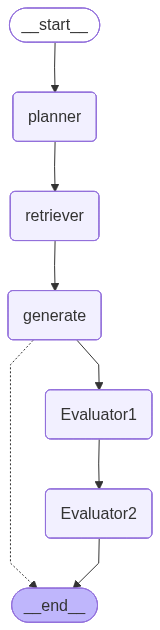

In [57]:
from IPython.display import Image

#Image(graph.get_graph().draw_png())
Image(graph.get_graph().draw_mermaid_png())


In [58]:
from IPython.display import Markdown, display

thread = {"configurable": {"thread_id": "1"}}

def print_pretty_output():
    initial_state = {
        "task": (
            "Evalúa cada uno de los CVs proporcionados. "
            "Indica las principales características del evaluado destacando sus fortalezas."
        ),
        "content": []
    }

    for event in graph.stream(initial_state, config=thread):
        display(Markdown(f"### Stream Event\n```\n{event}\n```"))

print_pretty_output()

### Stream Event
```
{'planner': {'plan': 'No valid CV content available.'}}
```

### Stream Event
```
{'retriever': {'context': ['tenders.', 'Master thesis: Evaluation of structural properties of Mn-doped GaN\n●', '2D.\nE d u c a t i o n\n●\nUniversity of Buenos Aires – Embedded Systems -\nSpecialization']}}
```

### Stream Event
```
{'generate': {'answer': 'The information is not available in the context.'}}
```

Queries: queries=[]


### Stream Event
```
{'Evaluator1': {'content': []}}
```

✅ Queries: queries=['What skills does {candidate_name} list?', 'What job roles has {candidate_name} held?', 'What relevant experience does {candidate_name} mention?', 'What certifications or courses does {candidate_name} include?', 'What industries or domains does {candidate_name} reference?']
Answer: I don't know.
Answer: The candidate has held the following job roles:

1. Machine Learning Engineer at Microsoft Azure AI (2016–2019)
2. AI Research Intern at Amazon Alexa AI (2015)
Answer: The candidate mentions experience working with technology companies including Google, Meta, and Microsoft. They are an expert in LLM architecture, retrieval systems, distributed training pipelines, and high-performance inference. Additionally, they have proven success in leading engineering teams to build reliable AI solutions serving millions of global users.
Answer: The candidate includes the following certifications and courses:

1. Google Professional Cloud Architect
2. TensorFlow Developer Certifi

### Stream Event
```
{'Evaluator2': {'content': ["I don't know.", 'The candidate has held the following job roles:\n\n1. Machine Learning Engineer at Microsoft Azure AI (2016–2019)\n2. AI Research Intern at Amazon Alexa AI (2015)', 'The candidate mentions experience working with technology companies including Google, Meta, and Microsoft. They are an expert in LLM architecture, retrieval systems, distributed training pipelines, and high-performance inference. Additionally, they have proven success in leading engineering teams to build reliable AI solutions serving millions of global users.', 'The candidate includes the following certifications and courses:\n\n1. Google Professional Cloud Architect\n2. TensorFlow Developer Certification\n3. Stanford Machine Learning Certificate (Andrew Ng)', 'The candidate references technology companies, specifically mentioning Google, Meta, and Microsoft. They are involved in the field of artificial intelligence, particularly in areas such as machine learning, LLM architecture, retrieval systems, and high-performance inference.']}}
```